## Step 1: Map problem to circuit

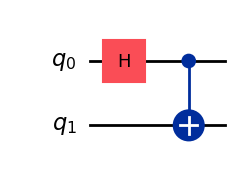

In [1]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

qc.draw(output="mpl")

In [2]:
from qiskit.quantum_info import Pauli

ZZ = Pauli("ZZ")
ZI = Pauli("ZI")
IZ = Pauli("IZ")
XX = Pauli("XX")
XI = Pauli("XI")

observables = [ZZ, ZI, IZ, XX, XI]

## Step 2: Optimize

## Step 3: Execute on backend

In [4]:
from qiskit_aer.primitives import Estimator

estimator = Estimator()

job = estimator.run([qc] * len(observables), observables)

job.result()

EstimatorResult(values=array([ 1.        ,  0.02929688,  0.02929688,  1.        , -0.00976562]), metadata=[{'shots': 1024, 'variance': 0.0, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0088728, 'sample_measure_time': 0.0018127, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 16077, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 12, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 0.9991416931152344, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0088728, 'sample_measure_time': 0.0018127, 'input_qubit_ma

## Step 4: Post-processing and plotting

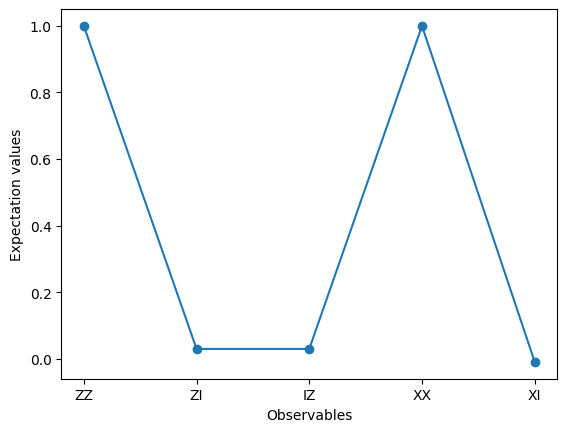

In [5]:
import matplotlib.pyplot as plt

data = ["ZZ", "ZI", "IZ", "XX", "XI"]
values = job.result().values

plt.plot(data, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Expectation values")
plt.show()

# Extending to an $n$-qbit GHZ state

## Step 1

In [12]:
def get_nqbit_gc(n):
    qc = QuantumCircuit(n)
    qc.h(0)
    for i in range(n-1):
        qc.cx(i, i + 1)
    return qc

n = 100

qc = get_nqbit_gc(n)
# qc.draw(output="mpl")

In [13]:
from qiskit.quantum_info import SparsePauliOp

operator_strings = ["Z" + "I" * i + "Z" + "I" * (n-2-i) for i in range(n-1)]
# print(operator_strings)
print(len(operator_strings))

operators = [SparsePauliOp(operator_string) for operator_string in operator_strings]

99


## Step 2

In [14]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend_name = "ibm_brisbane"
backend = QiskitRuntimeService().backend(backend_name)
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)

qc_traspiled = pass_manager.run(qc)
operators_transpiled_list = [op.apply_layout(qc_traspiled.layout) for op in operators]

## Step 3

In [20]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import EstimatorOptions

options = EstimatorOptions()
options.resilience_level = 1
# options.optimization_level = 0
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = "XY4"

estimator = Estimator(backend, options=options)

job = estimator.run([(qc_traspiled, operators_transpiled_list)])
job_id = job.job_id()
print(job_id)

czcgfwq4spc000877tc0


## Step 4

In [21]:
job_id = "czcgfwq4spc000877tc0"

service = QiskitRuntimeService()
job = service.job(job_id)

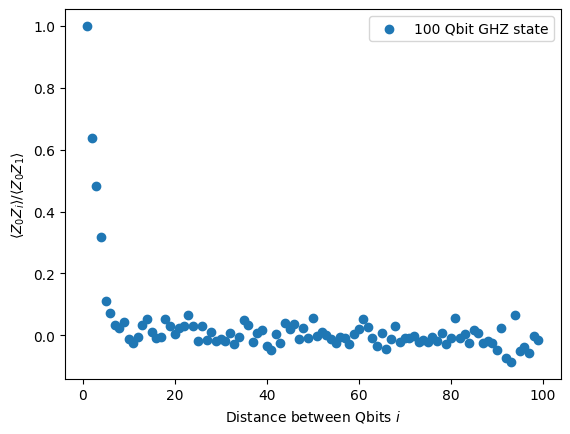

In [27]:
import matplotlib.pyplot as plt

data = list(range(1, len(operators)+1))
result = job.result()[0]
values = result.data.evs
values = [v / values[0] for v in values]

plt.scatter(data, values, marker="o", label="100 Qbit GHZ state")
plt.xlabel("Distance between Qbits $i$")
plt.ylabel(r'$\langle Z_0 Z_i \rangle / \langle Z_0 Z_1 \rangle$')
plt.legend()
plt.show()